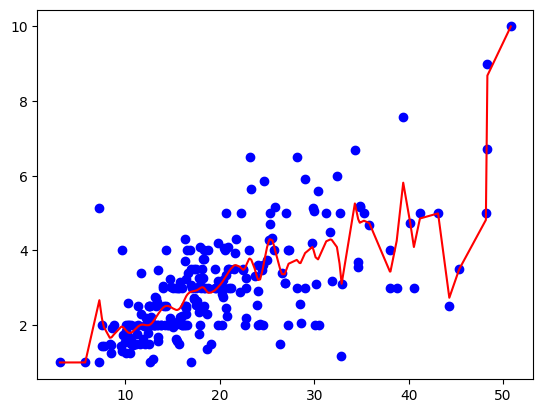

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def kernel(p, X, k): 
    return np.diag(np.exp(np.sum((X-p)**2, axis=1)/(-2*k**2)))

def predict(X, y, k=0.5):
    yp = np.zeros(len(X))
    for i,p in enumerate(X):
        w = kernel(p, X, k)
        yp[i] = p @ np.linalg.inv(X.T@w@X) @ X.T @ w @ y
    return yp

data = pd.read_csv(r"C:\Users\Noodl\Downloads\MLLab_Compact_Preserved\10-dataset (1).csv")
X = np.c_[np.ones(len(data)), data.total_bill]
y = data.tip.values

yp = predict(X, y)

s = X[:,1].argsort()
plt.scatter(data.total_bill, data.tip, color='blue')
plt.plot(X[s,1], yp[s], color='red')
plt.show()
